In [10]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE promptlogs (
    logid INT PRIMARY KEY,
    userid TEXT,
    modelname TEXT,
    prompttokens INT,
    completiontokens INT,
    totaltokens INT,
    latencyms INT,
    costusd DECIMAL(6,4),
    feedbackscore INT,
    createdat TEXT
);
''')

cursor.executemany('''
INSERT INTO promptlogs VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
''', [
    (101, 'usr001', 'gpt-4o', 350, 150, 500, 1200, 0.0050, 5, '2026-03-01 10:15:00'),
    (102, 'usr002', 'gpt-4o-mini', 800, 200, 1000, 450, 0.0003, 4, '2026-03-01 10:18:30'),
    (103, 'usr001', 'claude-3-5-sonnet', 1200, 450, 1650, 2100, 0.0098, 5, '2026-03-01 11:02:10'),
    (104, 'usr003', 'gpt-4o', 150, 600, 750, 3100, 0.0090, 2, '2026-03-01 11:45:12'),
    (105, 'usr004', 'gpt-4o-mini', 250, 100, 350, 380, 0.0001, 3, '2026-03-01 12:00:00'),
    (106, 'usr002', 'claude-3-5-sonnet', 450, 300, 750, 1600, 0.0045, 4, '2026-03-01 13:22:05'),
    (107, 'usr005', 'gpt-4o', 2100, 850, 2950, 4800, 0.0330, 1, '2026-03-01 14:10:44'),
    (108, 'usr003', 'gpt-4o-mini', 500, 150, 650, 510, 0.0002, 5, '2026-03-01 15:30:19'),
    (109, 'usr001', 'claude-3-5-sonnet', 950, 400, 1350, 1950, 0.0081, 4, '2026-03-01 16:05:00'),
    (110, 'usr004', 'gpt-4o', 600, 250, 850, 1850, 0.0085, 3, '2026-03-01 16:40:22')
])

conn.commit()

query = """
SELECT
    modelname,
    COUNT(logid) AS totalrequests,
    ROUND(AVG(latencyms), 2) AS avglatencyms,
    ROUND(AVG(totaltokens), 2) AS avgtokensperrequest,
    SUM(costusd) AS totalcostusd,
    ROUND(AVG(feedbackscore), 2) AS avgfeedbackrating
FROM promptlogs
GROUP BY modelname
ORDER BY avglatencyms ASC;
"""

df = pd.read_sql_query(query, conn)
df

,modelname,totalrequests,avglatencyms,avgtokensperrequest,totalcostusd,avgfeedbackrating
0,gpt-4o-mini,3,446.67,666.67,0.0006,4.00
1,claude-3-5-sonnet,3,1883.33,1250.00,0.0224,4.33
2,gpt-4o,4,2737.50,1262.50,0.0555,2.75


In [11]:
queryoutliers = """
SELECT
    logid,
    modelname,
    totaltokens,
    latencyms,
    costusd
FROM promptlogs
WHERE latencyms > (SELECT AVG(latencyms) FROM promptlogs)
ORDER BY latencyms DESC;
"""

dfoutliers = pd.read_sql_query(queryoutliers, conn)
dfoutliers

,logid,modelname,totaltokens,latencyms,costusd
0,107,gpt-4o,2950,4800,0.0330
1,104,gpt-4o,750,3100,0.0090
2,103,claude-3-5-sonnet,1650,2100,0.0098
3,109,claude-3-5-sonnet,1350,1950,0.0081
4,110,gpt-4o,850,1850,0.0085


In [12]:
queryusers = """
SELECT
    userid,
    COUNT(logid) AS totalprompts,
    SUM(totaltokens) AS usertokens,
    ROUND(SUM(costusd), 4) AS usercost
FROM promptlogs
GROUP BY userid
ORDER BY usercost DESC;
"""

dfusers = pd.read_sql_query(queryusers, conn)
dfusers

,userid,totalprompts,usertokens,usercost
0,usr005,1,2950,0.0330
1,usr001,3,3500,0.0229
2,usr003,2,1400,0.0092
3,usr004,2,1200,0.0086
4,usr002,2,1750,0.0048


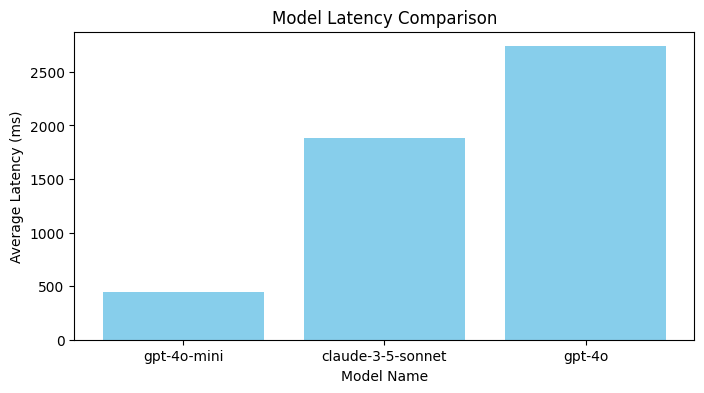

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(df['modelname'], df['avglatencyms'], color='skyblue')
plt.xlabel('Model Name')
plt.ylabel('Average Latency (ms)')
plt.title('Model Latency Comparison')
plt.show()

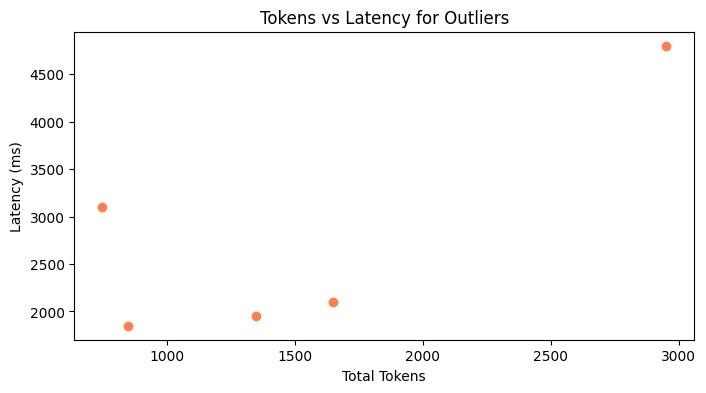

In [14]:
plt.figure(figsize=(8, 4))
plt.scatter(dfoutliers['totaltokens'], dfoutliers['latencyms'], color='coral')
plt.xlabel('Total Tokens')
plt.ylabel('Latency (ms)')
plt.title('Tokens vs Latency for Outliers')
plt.show()